In [ ]:
from google.colab import files
uploaded = files.upload()


Saving kc_house_data.csv to kc_house_data.csv


In [ ]:
import pandas as pd
pd.set_option('display.max_column',None)
df=pd.read_csv('kc_house_data.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqmeters_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180.0,109.62554,5650,1.0,no,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570.0,238.76071,7242,2.0,no,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770.0,71.53531,10000,1.0,no,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960.0,182.08988,5000,1.0,no,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680.0,156.07704,8080,1.0,no,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530.0,142.14159,1131,3.0,no,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310.0,214.60593,5813,2.0,no,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020.0,94.76106,1350,2.0,no,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600.0,148.64480,2388,2.0,no,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
import pandas as pd


nan_check = df.isnull()


nan_count = df.isnull().sum()

print("NaN Check:")
print(nan_check)
print("\nNaN Count per column:")
print(nan_count)


NaN Check:
          id   date  price  bedrooms  bathrooms  sqft_living  sqmeters_living  \
0      False  False  False     False      False        False            False   
1      False  False  False     False      False        False            False   
2      False  False  False     False      False        False            False   
3      False  False  False     False      False        False            False   
4      False  False  False     False      False        False            False   
...      ...    ...    ...       ...        ...          ...              ...   
21608  False  False  False     False      False        False            False   
21609  False  False  False     False      False        False            False   
21610  False  False  False     False      False        False            False   
21611  False  False  False     False      False        False            False   
21612  False  False  False     False      False        False            False   

       sqft_lot 

Outliers detected using Z-score:
Feature_1     55
Feature_2     49
Feature_3     53
Feature_4     51
Feature_5     53
Feature_6     55
Feature_7     59
Feature_8     61
Feature_9     57
Feature_10    62
Feature_11    52
Feature_12    66
Feature_13    59
Feature_14    58
Feature_15    57
Feature_16    47
Feature_17    62
Feature_18    48
Feature_19    58
Feature_20    54
Feature_21    56
Feature_22    72
dtype: int64

Outliers detected using IQR:
Feature_1     144
Feature_2     148
Feature_3     129
Feature_4     131
Feature_5     160
Feature_6     152
Feature_7     140
Feature_8     156
Feature_9     156
Feature_10    166
Feature_11    147
Feature_12    160
Feature_13    151
Feature_14    146
Feature_15    141
Feature_16    134
Feature_17    152
Feature_18    151
Feature_19    163
Feature_20    152
Feature_21    146
Feature_22    181
dtype: int64


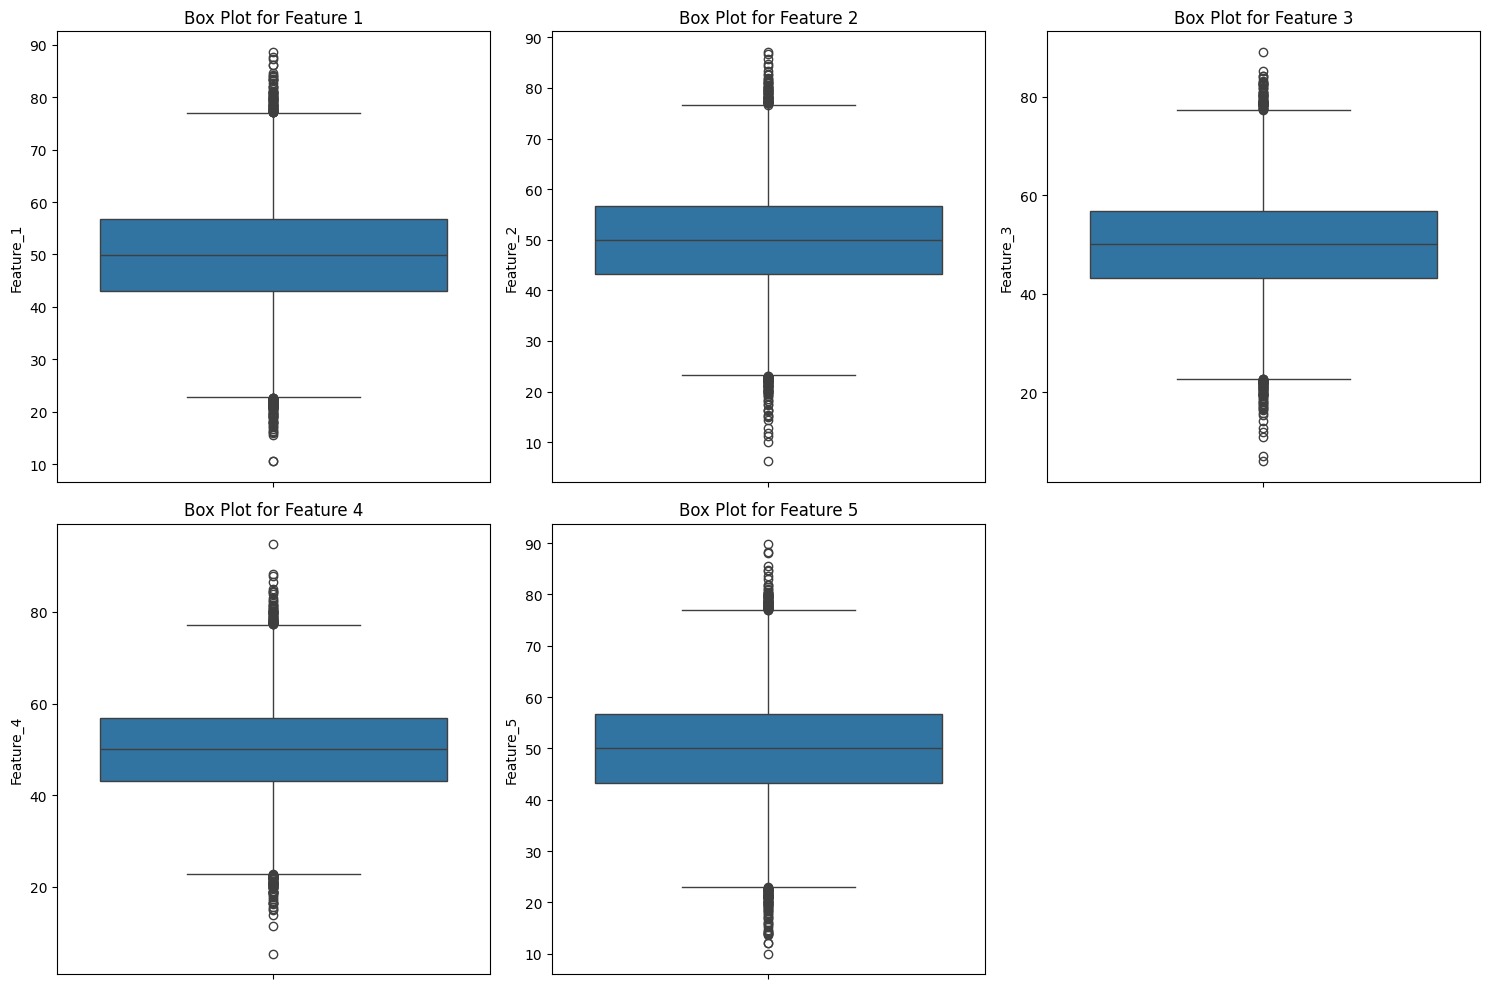

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# df = pd.read_csv('kc_house_data.csv')

np.random.seed(42)
data = np.random.randn(21613, 22) * 10 + 50  # Simulated data
df = pd.DataFrame(data, columns=[f'Feature_{i}' for i in range(1, 23)])

# Function to check for outliers using Z-score
def detect_outliers_zscore(dataframe):
    z_scores = np.abs((dataframe - dataframe.mean()) / dataframe.std())
    return (z_scores > 3)

# Function to check for outliers using IQR
def detect_outliers_iqr(dataframe):
    Q1 = dataframe.quantile(0.25)
    Q3 = dataframe.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (dataframe < lower_bound) | (dataframe > upper_bound)
outliers_zscore = detect_outliers_zscore(df)
outliers_iqr = detect_outliers_iqr(df)

# Count outliers for each method
outlier_counts_zscore = outliers_zscore.sum()
outlier_counts_iqr = outliers_iqr.sum()

# Print outlier counts
print("Outliers detected using Z-score:")
print(outlier_counts_zscore)

print("\nOutliers detected using IQR:")
print(outlier_counts_iqr)

# Visualize outliers with box plots for the first few features
plt.figure(figsize=(15, 10))
for i in range(5):  # Adjust to visualize more features
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df.iloc[:, i])
    plt.title(f'Box Plot for Feature {i + 1}')
plt.tight_layout()
plt.show()


In [ ]:

duplicates = df.duplicated()


duplicate_count = df.duplicated().sum()

print("\nDuplicates Check:")
print(duplicates)
print("\nTotal Duplicate Rows:")
print(duplicate_count)



Duplicates Check:
0        False
1        False
2        False
3        False
4        False
         ...  
21608    False
21609    False
21610    False
21611    False
21612    False
Length: 21613, dtype: bool

Total Duplicate Rows:
0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers_histogram(df):
    # Set the style for the plots
    sns.set(style='whitegrid')

    for column in df.select_dtypes(include=[np.number]).columns:
        plt.figure(figsize=(10, 6))

        # Calculate Q1, Q3, and IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Plot histogram with KDE
        sns.histplot(df[column], bins=30, kde=True, color='skyblue')
        plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
        plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

        # Highlight outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        if not outliers.empty:
            plt.scatter(outliers[column], np.zeros_like(outliers[column]), color='orange', label='Outliers', alpha=0.5)

        plt.title(f'Histogram of {column} with Outliers')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()



In [ ]:
import pandas as pd
# df = pd.read_csv('kc_house_data.csv')
# Replace 'date_column' with the name of your date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # Convert to datetime
df['date'] = df['date'].dt.strftime('%d/%m/%Y')  # Format to day/month/year

# Display the updated DataFrame
print(df)


               id        date     price  bedrooms  bathrooms  sqft_living  \
0      7129300520  13/10/2014  221900.0         3       1.00       1180.0   
1      6414100192  09/12/2014  538000.0         3       2.25       2570.0   
2      5631500400  25/02/2015  180000.0         2       1.00        770.0   
3      2487200875  09/12/2014  604000.0         4       3.00       1960.0   
4      1954400510  18/02/2015  510000.0         3       2.00       1680.0   
...           ...         ...       ...       ...        ...          ...   
21608   263000018  21/05/2014  360000.0         3       2.50       1530.0   
21609  6600060120  23/02/2015  400000.0         4       2.50       2310.0   
21610  1523300141  23/06/2014  402101.0         2       0.75       1020.0   
21611   291310100  16/01/2015  400000.0         3       2.50       1600.0   
21612  1523300157  15/10/2014  325000.0         2       0.75       1020.0   

       sqmeters_living  sqft_lot  floors waterfront  ...  grade  sqft_above

<ipython-input-31-af634b1f04f7>:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')  # Convert to datetime


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


In [ ]:
import pandas as pd
pd.set_option('display.max_column',None)
df=pd.read_csv('kc_house_data.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqmeters_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180.0,109.62554,5650,1.0,no,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570.0,238.76071,7242,2.0,no,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770.0,71.53531,10000,1.0,no,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960.0,182.08988,5000,1.0,no,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680.0,156.07704,8080,1.0,no,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530.0,142.14159,1131,3.0,no,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310.0,214.60593,5813,2.0,no,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020.0,94.76106,1350,2.0,no,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600.0,148.64480,2388,2.0,no,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
import pandas as pd


nan_check = df.isnull()


nan_count = df.isnull().sum()

print("NaN Check:")
print(nan_check)
print("\nNaN Count per column:")
print(nan_count)

NaN Check:
          id   date  price  bedrooms  bathrooms  sqft_living  sqmeters_living  \
0      False  False  False     False      False        False            False   
1      False  False  False     False      False        False            False   
2      False  False  False     False      False        False            False   
3      False  False  False     False      False        False            False   
4      False  False  False     False      False        False            False   
...      ...    ...    ...       ...        ...          ...              ...   
21608  False  False  False     False      False        False            False   
21609  False  False  False     False      False        False            False   
21610  False  False  False     False      False        False            False   
21611  False  False  False     False      False        False            False   
21612  False  False  False     False      False        False            False   

       sqft_lot 

Outliers detected using Z-score:
Feature_1     55
Feature_2     49
Feature_3     53
Feature_4     51
Feature_5     53
Feature_6     55
Feature_7     59
Feature_8     61
Feature_9     57
Feature_10    62
Feature_11    52
Feature_12    66
Feature_13    59
Feature_14    58
Feature_15    57
Feature_16    47
Feature_17    62
Feature_18    48
Feature_19    58
Feature_20    54
Feature_21    56
Feature_22    72
dtype: int64

Outliers detected using IQR:
Feature_1     144
Feature_2     148
Feature_3     129
Feature_4     131
Feature_5     160
Feature_6     152
Feature_7     140
Feature_8     156
Feature_9     156
Feature_10    166
Feature_11    147
Feature_12    160
Feature_13    151
Feature_14    146
Feature_15    141
Feature_16    134
Feature_17    152
Feature_18    151
Feature_19    163
Feature_20    152
Feature_21    146
Feature_22    181
dtype: int64


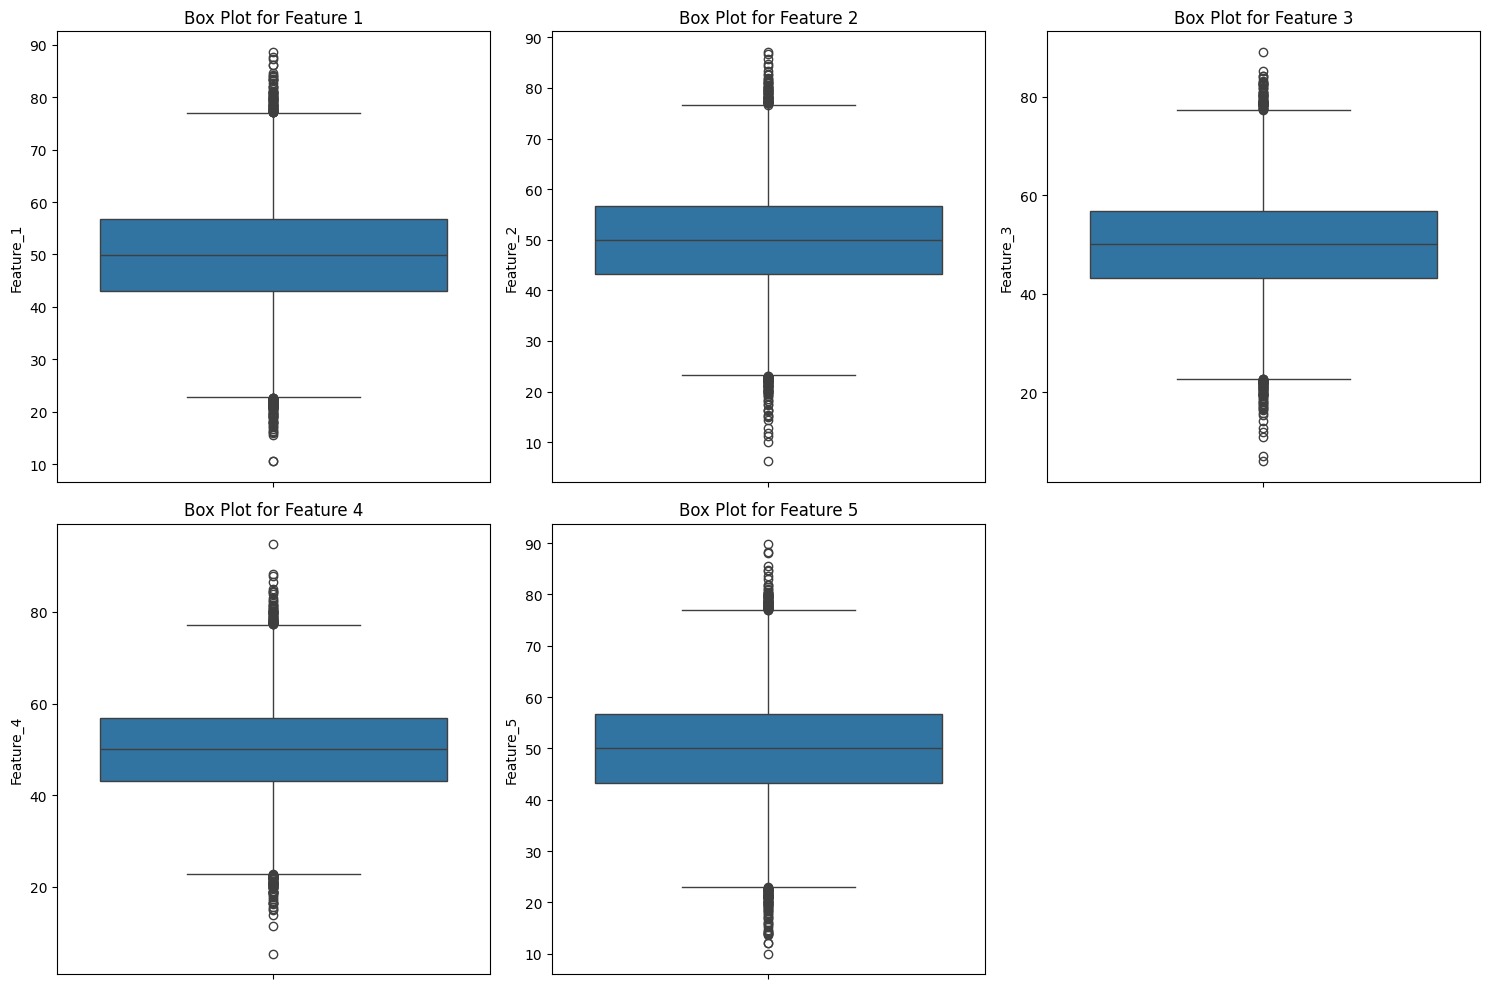

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# df = pd.read_csv('kc_house_data.csv')

np.random.seed(42)
data = np.random.randn(21613, 22) * 10 + 50  # Simulated data
df = pd.DataFrame(data, columns=[f'Feature_{i}' for i in range(1, 23)])

# Function to check for outliers using Z-score
def detect_outliers_zscore(dataframe):
    z_scores = np.abs((dataframe - dataframe.mean()) / dataframe.std())
    return (z_scores > 3)

# Function to check for outliers using IQR
def detect_outliers_iqr(dataframe):
    Q1 = dataframe.quantile(0.25)
    Q3 = dataframe.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (dataframe < lower_bound) | (dataframe > upper_bound)
outliers_zscore = detect_outliers_zscore(df)
outliers_iqr = detect_outliers_iqr(df)

# Count outliers for each method
outlier_counts_zscore = outliers_zscore.sum()
outlier_counts_iqr = outliers_iqr.sum()

# Print outlier counts
print("Outliers detected using Z-score:")
print(outlier_counts_zscore)

print("\nOutliers detected using IQR:")
print(outlier_counts_iqr)

# Visualize outliers with box plots for the first few features
plt.figure(figsize=(15, 10))
for i in range(5):  # Adjust to visualize more features
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df.iloc[:, i])
    plt.title(f'Box Plot for Feature {i + 1}')
plt.tight_layout()
plt.show()

In [ ]:
duplicates = df.duplicated()


duplicate_count = df.duplicated().sum()

print("\nDuplicates Check:")
print(duplicates)
print("\nTotal Duplicate Rows:")
print(duplicate_count)

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers_histogram(df):
    # Set the style for the plots
    sns.set(style='whitegrid')

    for column in df.select_dtypes(include=[np.number]).columns:
        plt.figure(figsize=(10, 6))

        # Calculate Q1, Q3, and IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Plot histogram with KDE
        sns.histplot(df[column], bins=30, kde=True, color='skyblue')
        plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
        plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

        # Highlight outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        if not outliers.empty:
            plt.scatter(outliers[column], np.zeros_like(outliers[column]), color='orange', label='Outliers', alpha=0.5)

        plt.title(f'Histogram of {column} with Outliers')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()
